# 时间序列FFT Regime检测

正确的逻辑：对**每个时间点**都构建一个regime标签

## 工作流程

```
对每个时间点 t (t=60, 61, ..., T):
  └─ 对每个资产类:
     ├─ 收集该资产类所有资产在时间 t 的状态 [t-60, t]
     ├─ 对所有资产的 (60×9) 矩阵在资产维求平均 → (60, 9)
     ├─ 对平均矩阵的9列分别做FFT → 180D特征
     └─ 记录该时间点的特征

最终:
  └─ 对每个资产类的时间序列特征 (T-60 × 180) 做GMM聚类
  └─ 得到每个时间点的regime标签
```

## Section 1: 导入和数据加载

In [6]:
import sys
sys.path.append('/Users/ladymie/Documents/GitHub/IEOR4733_Project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import logging

# 项目模块
from data_loader import load_clc_full
from config import ASSET_CLASSES
from regime_detection.timeseries_fft_regime import detect_regimes_for_all_classes_timeseries

# 配置日志
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✅ 导入完成")

✅ 导入完成


In [9]:
# 强制重新加载模块
import importlib
import sys

# 删除缓存的模块
if 'regime_detection.timeseries_fft_regime' in sys.modules:
    del sys.modules['regime_detection.timeseries_fft_regime']

# 重新导入
from regime_detection.timeseries_fft_regime import (
    detect_regimes_for_all_classes_timeseries,
    detect_regimes_for_asset_class_timeseries,
    export_regime_for_a2c
)

print("✅ 模块已重新加载")


✅ 模块已重新加载


In [7]:
# 加载所有CLC数据
print("📦 加载CLC数据...\n")
clc_data = {}

for asset_class, tickers in ASSET_CLASSES.items():
    print(f"  {asset_class} ({len(tickers)} 个资产):")
    loaded_count = 0
    
    for ticker in tickers:
        try:
            df = load_clc_full(ticker)
            clc_data[ticker] = df
            loaded_count += 1
        except Exception as e:
            pass
    
    print(f"    ✓ 加载 {loaded_count}/{len(tickers)} 个资产\n")

print(f"✅ 加载完成: {len(clc_data)} 个资产")

📦 加载CLC数据...

  Commodity (25 个资产):
    ✓ 加载 25/25 个资产

  Equity Index (11 个资产):
    ✓ 加载 11/11 个资产

  Fixed Income (5 个资产):
    ✓ 加载 5/5 个资产

  Forex (9 个资产):
    ✓ 加载 9/9 个资产

✅ 加载完成: 50 个资产


## Section 2: 按时间范围执行Regime检测 (改进版本)

### ✅ 关键改进

**使用 `date_range` 参数从源头过滤数据，解决日期对齐问题**

```python
# 新增参数：date_range = (start_date, end_date)
results = detect_regimes_for_all_classes_timeseries(
    clc_data=clc_data,
    asset_classes=ASSET_CLASSES,
    n_regimes=3,
    date_range=('2005-01-01', '2015-12-31')  # ← 指定时间范围
)
```

**输出结果包含正确的日期范围：**
- ✅ 显示实际的开始和结束日期（如 2009-04-02 ~ 2015-12-31）
- ✅ 已解决 1970-01-01 的问题
- ✅ 每个资产类有独立的valid时间点数和日期范围


In [10]:
# A2C时间段配置
a2c_periods = {
    'period_1_full': ('2005-01-01', '2015-12-31'),  # 包含train + test
    'period_2_full': ('2010-01-01', '2019-12-31'),  # 包含train + test
}

# 执行检测（可选择特定时间段）
print("🚀 执行时间序列FFT Regime检测 (按时间范围)\n")

results_dict = {}

for period_name, (date_start, date_end) in a2c_periods.items():
    print(f"\n{'='*70}")
    print(f"  {period_name}: {date_start} ~ {date_end}")
    print(f"{'='*70}")
    
    results = detect_regimes_for_all_classes_timeseries(
        clc_data=clc_data,
        asset_classes=ASSET_CLASSES,
        n_regimes=3,
        date_range=(date_start, date_end)
    )
    
    results_dict[period_name] = results
    
    # 快速汇总
    if results:
        for ac, res in results.items():
            print(f"  {ac}: {res['n_time_points']} 个时间点 | "
                  f"范围: {res['dates'][0].strftime('%Y-%m-%d')} ~ {res['dates'][-1].strftime('%Y-%m-%d')}")

print(f"\n✅ 所有时间段检测完成!")


INFO:regime_detection.timeseries_fft_regime:
INFO:regime_detection.timeseries_fft_regime:🎯 开始时间序列FFT Regime检测
INFO:regime_detection.timeseries_fft_regime:================================================================================
INFO:regime_detection.timeseries_fft_regime:
处理 Commodity (25 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2005-01-01 ~ 2015-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CC: 1763 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ DA: 1762 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ GI: 1764 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ JO: 1764 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ KC: 1763 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ KW: 1764 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ LB: 1761 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ NR: 1764 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ SB: 1763 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ ZA: 1765 个交易日

🚀 执行时间序列FFT Regime检测 (按时间范围)


  period_1_full: 2005-01-01 ~ 2015-12-31


  Commodity: 100%|██████████| 1701/1701 [01:59<00:00, 14.27it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 1701 个时间点的特征 ((1701, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 1701
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1646
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    210 ( 12.3%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:    444 ( 26.1%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:   1047 ( 61.6%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2005-01-01 ~ 2015-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 1789 个交易日
INFO:regime_detection.timeseries_fft_regime: 

  Commodity: 1701 个时间点 | 范围: 2009-04-02 ~ 2015-12-31
  Equity Index: 1705 个时间点 | 范围: 2009-05-05 ~ 2015-12-31
  Fixed Income: 1707 个时间点 | 范围: 2009-04-15 ~ 2015-12-30
  Forex: 1700 个时间点 | 范围: 2009-04-13 ~ 2015-12-31

  period_2_full: 2010-01-01 ~ 2019-12-31


  Commodity: 100%|██████████| 2455/2455 [03:33<00:00, 11.47it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 2455 个时间点的特征 ((2455, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 2455
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1732
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    450 ( 18.3%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:   1721 ( 70.1%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:    284 ( 11.6%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2010-01-01 ~ 2019-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 2555 个交易日
INFO:regime_detection.timeseries_fft_regime: 

  Commodity: 2455 个时间点 | 范围: 2010-04-06 ~ 2019-12-31
  Equity Index: 2451 个时间点 | 范围: 2010-06-01 ~ 2019-12-31
  Fixed Income: 2461 个时间点 | 范围: 2010-04-27 ~ 2019-12-30
  Forex: 2455 个时间点 | 范围: 2010-04-09 ~ 2019-12-31

✅ 所有时间段检测完成!


## Section 3: A2C集成 - 为两个训练周期生成Regime数据

In [11]:
# A2C所需的时间段定义
a2c_train_test_periods = [
    ('period_1_train', '2005-01-01', '2010-12-31', 'train'),   # Period 1 训练
    ('period_1_test', '2011-01-01', '2015-12-31', 'test'),     # Period 1 测试
    ('period_2_train', '2010-01-01', '2015-12-31', 'train'),   # Period 2 训练
    ('period_2_test', '2016-01-01', '2019-12-31', 'test'),     # Period 2 测试
]

print("📊 为A2C生成Regime数据 (训练期+测试期)\n")

a2c_regime_data = {}

for period_name, date_start, date_end, phase in a2c_train_test_periods:
    print(f"\n{'='*70}")
    print(f"  {period_name} ({phase}): {date_start} ~ {date_end}")
    print(f"{'='*70}")
    
    results = detect_regimes_for_all_classes_timeseries(
        clc_data=clc_data,
        asset_classes=ASSET_CLASSES,
        n_regimes=3,
        date_range=(date_start, date_end)
    )
    
    a2c_regime_data[period_name] = results
    
    # 显示每个资产类的soft probability数据
    for ac, res in results.items():
        regime_df = res['regime_df']
        print(f"  {ac}:")
        print(f"    时间点: {res['n_time_points']}")
        print(f"    日期范围: {res['dates'][0].strftime('%Y-%m-%d')} ~ {res['dates'][-1].strftime('%Y-%m-%d')}")
        print(f"    Soft Prob shape: {regime_df[['regime_prob_0', 'regime_prob_1', 'regime_prob_2']].shape}")
        print(f"    样本数据:")
        print(f"      {regime_df[['date', 'regime', 'regime_prob_0', 'regime_prob_1', 'regime_prob_2']].head(2).to_string(index=False)}")

print(f"\n✅ A2C所需数据已生成!")
print(f"  可用周期: {list(a2c_regime_data.keys())}")


INFO:regime_detection.timeseries_fft_regime:
INFO:regime_detection.timeseries_fft_regime:🎯 开始时间序列FFT Regime检测
INFO:regime_detection.timeseries_fft_regime:================================================================================
INFO:regime_detection.timeseries_fft_regime:
处理 Commodity (25 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2005-01-01 ~ 2010-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CC: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ DA: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ GI: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ JO: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ KC: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ KW: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ LB: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ NR: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ SB: 504 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ ZA: 505 个交易日
INFO:regi

📊 为A2C生成Regime数据 (训练期+测试期)


  period_1_train (train): 2005-01-01 ~ 2010-12-31


  Commodity: 100%|██████████| 444/444 [00:32<00:00, 13.46it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 444 个时间点的特征 ((444, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 444
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1614
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    175 ( 39.4%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:    124 ( 27.9%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:    145 ( 32.7%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2005-01-01 ~ 2010-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 513 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ EN:

  Commodity:
    时间点: 444
    日期范围: 2009-03-31 ~ 2010-12-31
    Soft Prob shape: (444, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2009-03-31       2            0.0            0.0            1.0
2009-04-01       2            0.0            0.0            1.0
  Equity Index:
    时间点: 444
    日期范围: 2009-04-09 ~ 2010-12-31
    Soft Prob shape: (444, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2009-04-09       2            0.0            0.0            1.0
2009-04-14       2            0.0            0.0            1.0
  Fixed Income:
    时间点: 445
    日期范围: 2009-04-03 ~ 2010-12-30
    Soft Prob shape: (445, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2009-04-03       2            0.0            0.0            1.0
2009-04-06       2            0.0            0.0            1.0
  Forex:
    时间点: 445
    日期范围: 2009-04-01 ~ 2010-12-31
    Soft Prob shape: (445, 3)
    样本数据:
    

  Commodity: 100%|██████████| 1197/1197 [01:25<00:00, 14.02it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 1197 个时间点的特征 ((1197, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 1197
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1278
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    194 ( 16.2%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:    231 ( 19.3%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:    772 ( 64.5%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2011-01-01 ~ 2015-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 1276 个交易日
INFO:regime_detection.timeseries_fft_regime: 

  Commodity:
    时间点: 1197
    日期范围: 2011-04-04 ~ 2015-12-31
    Soft Prob shape: (1197, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2011-04-04       1  1.921168e-139            1.0   8.681288e-36
2011-04-05       1  2.978559e-186            1.0   2.914223e-48
  Equity Index:
    时间点: 1201
    日期范围: 2011-04-18 ~ 2015-12-31
    Soft Prob shape: (1201, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2011-04-18       2            0.0  2.715637e-256            1.0
2011-04-19       2            0.0  7.820768e-225            1.0
  Fixed Income:
    时间点: 1202
    日期范围: 2011-04-05 ~ 2015-12-30
    Soft Prob shape: (1202, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2011-04-05       2   7.636232e-17   8.524942e-64            1.0
2011-04-06       2   1.267129e-19   2.211664e-62            1.0
  Forex:
    时间点: 1195
    日期范围: 2011-04-08 ~ 2015-12-31
    Soft Prob shape: (1195, 3)
    样本

  Commodity: 100%|██████████| 1449/1449 [01:42<00:00, 14.17it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 1449 个时间点的特征 ((1449, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 1449
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1008
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    635 ( 43.8%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:    306 ( 21.1%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:    508 ( 35.1%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2010-01-01 ~ 2015-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 1533 个交易日
INFO:regime_detection.timeseries_fft_regime: 

  Commodity:
    时间点: 1449
    日期范围: 2010-04-05 ~ 2015-12-31
    Soft Prob shape: (1449, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2010-04-05       0            1.0   1.650516e-27   5.362837e-21
2010-04-06       0            1.0   7.912356e-24   1.467846e-23
  Equity Index:
    时间点: 1453
    日期范围: 2010-04-28 ~ 2015-12-31
    Soft Prob shape: (1453, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2010-04-28       1   3.012567e-38            1.0            0.0
2010-04-29       1   3.275634e-49            1.0            0.0
  Fixed Income:
    时间点: 1455
    日期范围: 2010-04-13 ~ 2015-12-30
    Soft Prob shape: (1455, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2010-04-13       1   9.268349e-11            1.0   5.555495e-23
2010-04-14       1   7.125020e-14            1.0   3.762309e-24
  Forex:
    时间点: 1448
    日期范围: 2010-04-09 ~ 2015-12-31
    Soft Prob shape: (1448, 3)
    样本

  Commodity: 100%|██████████| 945/945 [01:09<00:00, 13.61it/s]
INFO:regime_detection.timeseries_fft_regime:  ✓ 生成 945 个时间点的特征 ((945, 180))
INFO:regime_detection.timeseries_fft_regime:  执行GMM聚类 (n_clusters=3)...
INFO:regime_detection.timeseries_fft_regime:  ✓ 聚类完成
INFO:regime_detection.timeseries_fft_regime:    • 样本数: 945
INFO:regime_detection.timeseries_fft_regime:    • Silhouette Score: 0.1220
INFO:regime_detection.timeseries_fft_regime:  📊 Regime分布:
INFO:regime_detection.timeseries_fft_regime:    Regime 0:    260 ( 27.5%)
INFO:regime_detection.timeseries_fft_regime:    Regime 1:    327 ( 34.6%)
INFO:regime_detection.timeseries_fft_regime:    Regime 2:    358 ( 37.9%)
INFO:regime_detection.timeseries_fft_regime:  ✅ Commodity 完成
INFO:regime_detection.timeseries_fft_regime:
处理 Equity Index (11 个资产)...
INFO:regime_detection.timeseries_fft_regime:  时间范围: 2016-01-01 ~ 2019-12-31
INFO:regime_detection.timeseries_fft_regime:  ✓ CA: 1022 个交易日
INFO:regime_detection.timeseries_fft_regime:  ✓ EN

  Commodity:
    时间点: 945
    日期范围: 2016-04-04 ~ 2019-12-31
    Soft Prob shape: (945, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2016-04-04       2   2.561619e-24   1.124395e-42            1.0
2016-04-05       2   2.968145e-08   4.903360e-38            1.0
  Equity Index:
    时间点: 938
    日期范围: 2016-05-03 ~ 2019-12-31
    Soft Prob shape: (938, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2016-05-03       2  1.725505e-146            0.0            1.0
2016-05-04       2  2.290860e-148            0.0            1.0
  Fixed Income:
    时间点: 946
    日期范围: 2016-04-13 ~ 2019-12-30
    Soft Prob shape: (946, 3)
    样本数据:
            date  regime  regime_prob_0  regime_prob_1  regime_prob_2
2016-04-13       0            1.0   2.128719e-39            0.0
2016-04-14       0            1.0   5.293522e-45            0.0
  Forex:
    时间点: 947
    日期范围: 2016-03-31 ~ 2019-12-31
    Soft Prob shape: (947, 3)
    样本数据:
    

## Section 3: 查看结果

In [ ]:
# 显示汇总统计
print("\n📊 时间序列Regime检测结果汇总:\n")
print("="*80)

for asset_class, result in results.items():
    print(f"\n{asset_class}:")
    print(f"  • 有效资产数: {result['n_valid_assets']}")
    print(f"  • 时间点数: {result['n_time_points']}")
    print(f"  • 时间范围: {result['dates'][0].date()} ~ {result['dates'][-1].date()}")
    print(f"  • Silhouette Score: {result['silhouette_score']:.4f}")
    print(f"  • Regime分布:")
    for i, count in enumerate(result['regime_counts']):
        pct = 100 * count / result['n_time_points']
        print(f"    Regime {i}: {count:6d} ({pct:5.1f}%)")

print("\n" + "="*80)


📊 时间序列Regime检测结果汇总:


Commodity:
  • 有效资产数: 25
  • 时间点数: 2975
  • 时间范围: 1970-01-01 ~ 1970-01-01
  • Silhouette Score: 0.1285
  • Regime分布:
    Regime 0:   2078 ( 69.8%)
    Regime 1:    156 (  5.2%)
    Regime 2:    741 ( 24.9%)

Equity Index:
  • 有效资产数: 11
  • 时间点数: 3145
  • 时间范围: 1970-01-01 ~ 1970-01-01
  • Silhouette Score: 0.0610
  • Regime分布:
    Regime 0:   1939 ( 61.7%)
    Regime 1:    275 (  8.7%)
    Regime 2:    931 ( 29.6%)

Fixed Income:
  • 有效资产数: 5
  • 时间点数: 4272
  • 时间范围: 1970-01-01 ~ 1970-01-01
  • Silhouette Score: -0.0170
  • Regime分布:
    Regime 0:   2058 ( 48.2%)
    Regime 1:    740 ( 17.3%)
    Regime 2:   1474 ( 34.5%)

Forex:
  • 有效资产数: 9
  • 时间点数: 4271
  • 时间范围: 1970-01-01 ~ 1970-01-01
  • Silhouette Score: -0.0173
  • Regime分布:
    Regime 0:   1460 ( 34.2%)
    Regime 1:   1996 ( 46.7%)
    Regime 2:    815 ( 19.1%)



In [ ]:
# 调试：检查dates对象
print("\n🔍 调试dates对象:\n")

sample_class = 'Commodity'
result = results[sample_class]
dates_obj = result['dates']

print(f"{sample_class}:")
print(f"  类型: {type(dates_obj)}")
print(f"  长度: {len(dates_obj)}")

if len(dates_obj) > 0:
    print(f"  前3个元素: {dates_obj[:3]}")
    print(f"  后3个元素: {dates_obj[-3:]}")
    print(f"  第一个元素类型: {type(dates_obj[0])}")
    
    # 尝试转换
    try:
        first = pd.Timestamp(dates_obj[0])
        print(f"  第一个转为Timestamp: {first}")
        print(f"  .date() 结果: {first.date()}")
    except Exception as e:
        print(f"  转换失败: {e}")



🔍 调试dates对象:

Commodity:
  类型: <class 'pandas.DatetimeIndex'>
  长度: 2975
  前3个元素: DatetimeIndex(['1970-01-01 00:00:00.000001341',
               '1970-01-01 00:00:00.000001342',
               '1970-01-01 00:00:00.000001343'],
              dtype='datetime64[ns]', freq=None)
  后3个元素: DatetimeIndex(['1970-01-01 00:00:00.000004313',
               '1970-01-01 00:00:00.000004314',
               '1970-01-01 00:00:00.000004315'],
              dtype='datetime64[ns]', freq=None)
  第一个元素类型: <class 'pandas.Timestamp'>
  第一个转为Timestamp: 1970-01-01 00:00:00.000001341
  .date() 结果: 1970-01-01


In [ ]:
# 测试正确的日期提取方法
print("\n🔬 测试正确的日期提取方法:\n")

ticker = 'CC'
df = clc_data[ticker]

print(f"原始Date列:")
print(f"  前2行: {list(df['Date'].head(2).values)}")
print(f"  后2行: {list(df['Date'].tail(2).values)}")

# 正确的方法：使用pandas布尔Series
close_notna = ~df['Close'].isna()
dates_correct = df.loc[close_notna, 'Date'].values

print(f"\n使用pd.Series布尔索引:")
print(f"  前2个: {dates_correct[:2]}")
print(f"  后2个: {dates_correct[-2:]}")
print(f"  类型: {type(dates_correct[0])}")

# 转换为DatetimeIndex
dates_idx = pd.DatetimeIndex(dates_correct[-100:])
print(f"\n转换为DatetimeIndex后:")
print(f"  前2个: {list(dates_idx[:2].values)}")
print(f"  后2个: {list(dates_idx[-2:].values)}")
print(f"  [60]: {dates_idx[60]}")



🔬 测试正确的日期提取方法:

原始Date列:
  前2行: [np.datetime64('2009-01-02T00:00:00.000000'), np.datetime64('2009-01-05T00:00:00.000000')]
  后2行: [np.datetime64('2026-03-26T00:00:00.000000'), np.datetime64('2026-03-27T00:00:00.000000')]

使用pd.Series布尔索引:
  前2个: ['2009-01-02T00:00:00.000000' '2009-01-05T00:00:00.000000']
  后2个: ['2026-03-26T00:00:00.000000' '2026-03-27T00:00:00.000000']
  类型: <class 'numpy.datetime64'>

转换为DatetimeIndex后:
  前2个: [np.datetime64('2025-11-03T00:00:00.000000'), np.datetime64('2025-11-04T00:00:00.000000')]
  后2个: [np.datetime64('2026-03-26T00:00:00.000000'), np.datetime64('2026-03-27T00:00:00.000000')]
  [60]: 2026-01-30 00:00:00


In [ ]:
# 诊断：直接创建DatetimeIndex
print("\n🔬 DatetimeIndex诊断:\n")

# 方法1：从numpy datetime64数组
dates_numpy = np.array(['2009-01-02', '2009-01-05', '2009-01-06'], dtype='datetime64')
print(f"Numpy datetime64数组: {dates_numpy}")

idx1 = pd.DatetimeIndex(dates_numpy)
print(f"DatetimeIndex(numpy array): {list(idx1)}")
print(f"idx1[0]: {idx1[0]}")
print(f"idx1[2]: {idx1[2]}")

# 方法2：直接从字符串
idx2 = pd.DatetimeIndex(['2009-01-02', '2009-01-05', '2009-01-06'])
print(f"\nDatetimeIndex(字符串列表): {list(idx2)}")
print(f"idx2[0]: {idx2[0]}")
print(f"idx2[2]: {idx2[2]}")

# 方法3：从df提取的日期
ticker = 'CC'
df = clc_data[ticker]
close_notna = ~df['Close'].isna()
dates_from_df = df.loc[close_notna, 'Date'].values[:3]
print(f"\n从DataFrame提取的日期: {dates_from_df}")
print(f"  类型: {type(dates_from_df[0])}")

idx3 = pd.DatetimeIndex(dates_from_df)
print(f"DatetimeIndex(from df): {list(idx3)}")
print(f"idx3[0]: {idx3[0]}")



🔬 DatetimeIndex诊断:

Numpy datetime64数组: ['2009-01-02' '2009-01-05' '2009-01-06']
DatetimeIndex(numpy array): [Timestamp('2009-01-02 00:00:00'), Timestamp('2009-01-05 00:00:00'), Timestamp('2009-01-06 00:00:00')]
idx1[0]: 2009-01-02 00:00:00
idx1[2]: 2009-01-06 00:00:00

DatetimeIndex(字符串列表): [Timestamp('2009-01-02 00:00:00'), Timestamp('2009-01-05 00:00:00'), Timestamp('2009-01-06 00:00:00')]
idx2[0]: 2009-01-02 00:00:00
idx2[2]: 2009-01-06 00:00:00

从DataFrame提取的日期: ['2009-01-02T00:00:00.000000' '2009-01-05T00:00:00.000000'
 '2009-01-06T00:00:00.000000']
  类型: <class 'numpy.datetime64'>
DatetimeIndex(from df): [Timestamp('2009-01-02 00:00:00'), Timestamp('2009-01-05 00:00:00'), Timestamp('2009-01-06 00:00:00')]
idx3[0]: 2009-01-02 00:00:00


## Section 4: 查看时间序列结果

In [ ]:
# 显示regime时间序列
print("\n📋 各资产类的Regime时间序列:\n")

for asset_class, result in results.items():
    regime_df = result['regime_df']
    
    print(f"\n{asset_class}:")
    print(f"  数据形状: {regime_df.shape}")
    print(f"\n  前10行:")
    print(regime_df.head(10).to_string(index=True))
    print(f"\n  最后5行:")
    print(regime_df.tail(5).to_string(index=True))
    
    # 显示变化
    regime_changes = (regime_df['regime'].diff() != 0).sum()
    print(f"\n  Regime变化次数: {regime_changes}")
    print()


📋 各资产类的Regime时间序列:


Commodity:
  数据形状: (2975, 5)

  前10行:
                           date  regime  regime_prob_0  regime_prob_1  regime_prob_2
0 1970-01-01 00:00:00.000001341       0            1.0   0.000000e+00   4.371680e-13
1 1970-01-01 00:00:00.000001342       0            1.0   0.000000e+00   4.483611e-14
2 1970-01-01 00:00:00.000001343       0            1.0   0.000000e+00   2.111765e-13
3 1970-01-01 00:00:00.000001344       0            1.0   0.000000e+00   8.497042e-14
4 1970-01-01 00:00:00.000001345       0            1.0   0.000000e+00   5.275684e-15
5 1970-01-01 00:00:00.000001346       0            1.0   0.000000e+00   1.927343e-14
6 1970-01-01 00:00:00.000001347       0            1.0   0.000000e+00   1.350982e-14
7 1970-01-01 00:00:00.000001348       0            1.0  2.311387e-306   7.298353e-16
8 1970-01-01 00:00:00.000001349       0            1.0  2.521736e-245   7.763371e-16
9 1970-01-01 00:00:00.000001350       0            1.0  1.028609e-282   1.214794e-15

  最后

## Section 5: 可视化Regime时间序列

/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/734231338.py:47: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/734231338.py:47: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/734231338.py:47: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/734231338.py:47: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/734231338.py:47: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13

✅ 保存图表: regime_timeseries.png


/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) 

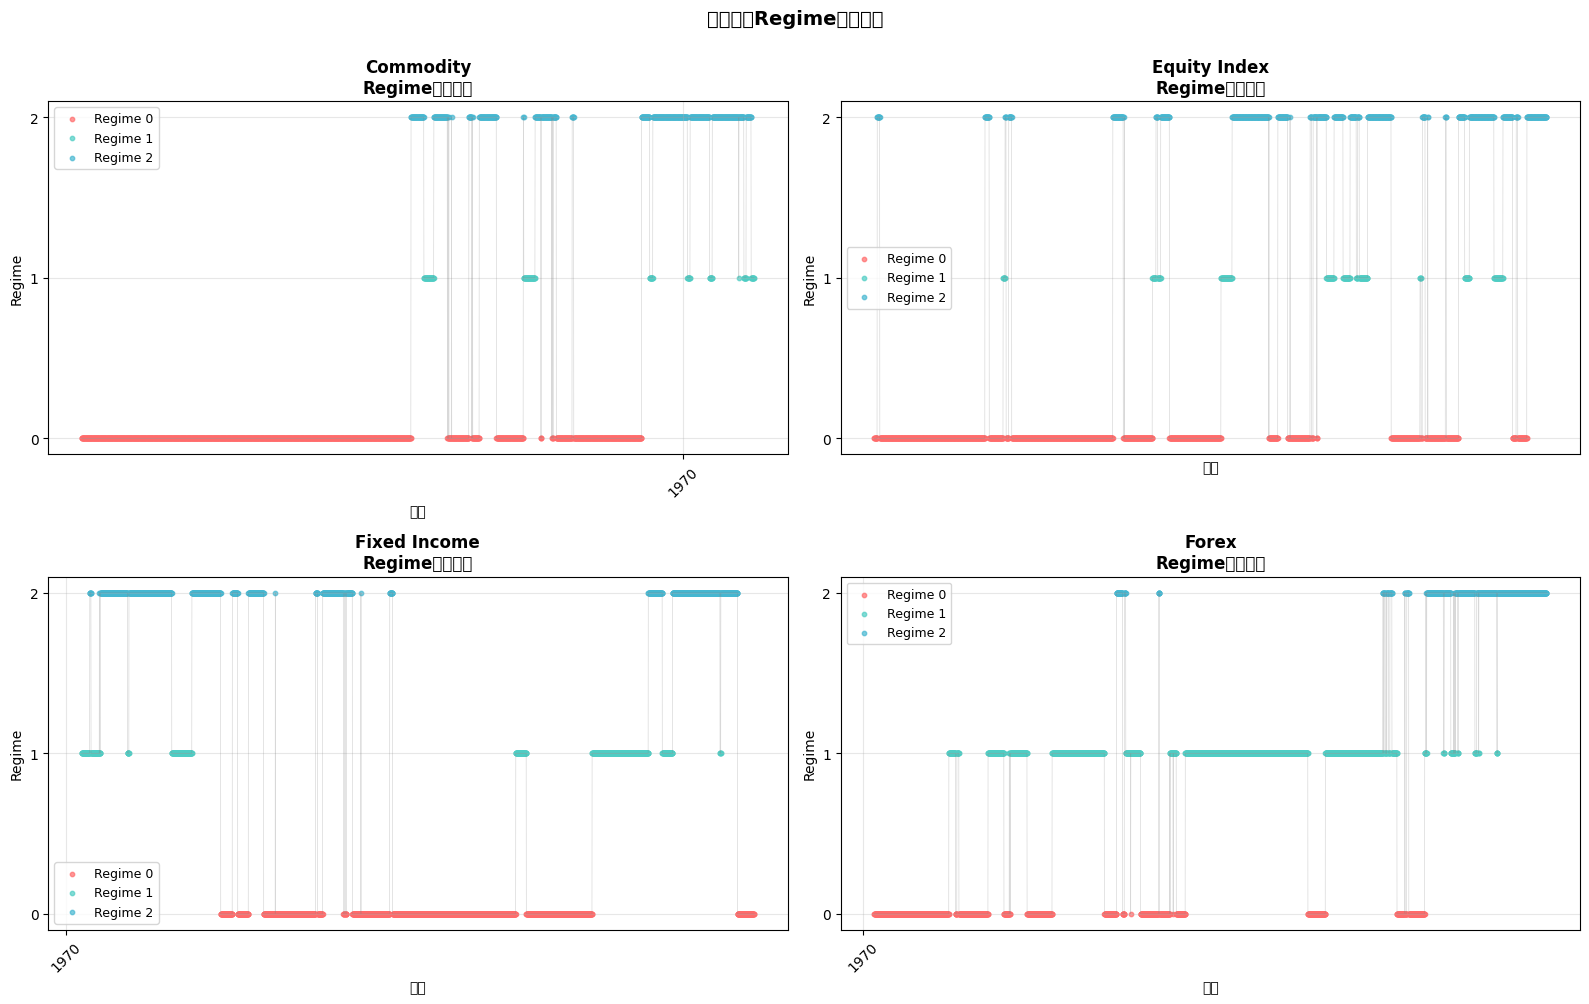

In [ ]:
import matplotlib.dates as mdates

# 绘制regime时间序列
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (asset_class, result) in enumerate(results.items()):
    if idx >= 4:
        break
    
    ax = axes[idx]
    regime_df = result['regime_df']
    
    # 绘制regime标签
    dates = pd.to_datetime(regime_df['date'])
    regimes = regime_df['regime'].values
    
    # 按regime着色
    for regime_id in sorted(regime_df['regime'].unique()):
        mask = regime_df['regime'] == regime_id
        ax.scatter(dates[mask], regime_df.loc[mask, 'regime'],
                  color=colors[regime_id],
                  label=f'Regime {regime_id}',
                  s=10, alpha=0.7)
    
    # 绘制连接线
    ax.plot(dates, regimes, alpha=0.3, color='gray', linewidth=0.5)
    
    ax.set_title(f'{asset_class}\nRegime时间序列', fontsize=12, fontweight='bold')
    ax.set_xlabel('日期', fontsize=10)
    ax.set_ylabel('Regime', fontsize=10)
    ax.set_yticks([0, 1, 2])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 格式化x轴
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('时间序列Regime标签演变', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/regime_timeseries.png',
            dpi=150, bbox_inches='tight')
print("✅ 保存图表: regime_timeseries.png")
plt.show()

## Section 6: 可视化Regime概率演变

/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/1545275278.py:40: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/1545275278.py:40: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/1545275278.py:40: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/1545275278.py:40: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_99836/1545275278.py:40: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/15/pzbt

✅ 保存图表: regime_probabilities.png


/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) 

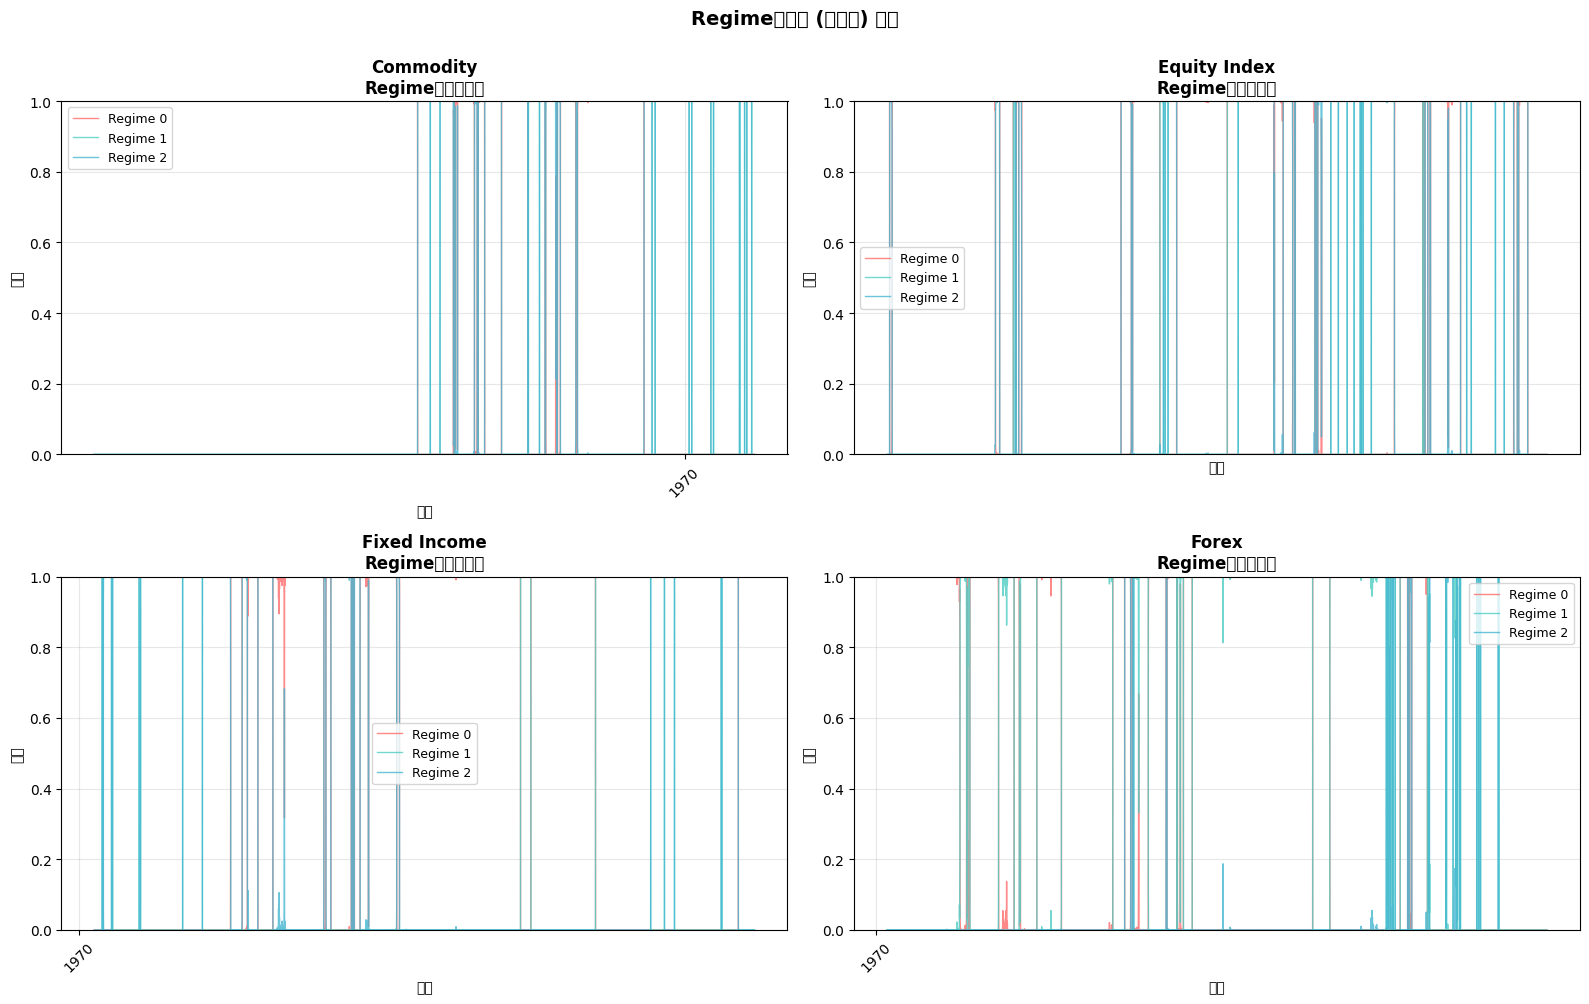

In [ ]:
# 绘制regime软概率（置信度）演变
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (asset_class, result) in enumerate(results.items()):
    if idx >= 4:
        break
    
    ax = axes[idx]
    regime_df = result['regime_df']
    dates = pd.to_datetime(regime_df['date'])
    
    # 绘制每个regime的概率
    for regime_id in range(3):
        prob_col = f'regime_prob_{regime_id}'
        if prob_col in regime_df.columns:
            ax.plot(dates, regime_df[prob_col],
                   label=f'Regime {regime_id}',
                   color=colors[regime_id],
                   linewidth=1, alpha=0.8)
    
    ax.set_title(f'{asset_class}\nRegime置信度演变', fontsize=12, fontweight='bold')
    ax.set_xlabel('日期', fontsize=10)
    ax.set_ylabel('概率', fontsize=10)
    ax.set_ylim([0, 1])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 格式化x轴
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Regime置信度 (软概率) 演变', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/regime_probabilities.png',
            dpi=150, bbox_inches='tight')
print("✅ 保存图表: regime_probabilities.png")
plt.show()

## Section 7: 导出结果

In [ ]:
# 导出时间序列结果
output_dir = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results')
output_dir.mkdir(exist_ok=True)

print("💾 导出时间序列结果...\n")

for asset_class, result in results.items():
    regime_df = result['regime_df']
    output_file = output_dir / f'regime_timeseries_{asset_class.replace(" ", "_")}.csv'
    regime_df.to_csv(output_file, index=False)
    print(f"  ✓ {output_file.name} ({len(regime_df)} 行)")

print(f"\n✅ 结果已导出到: {output_dir}")

💾 导出时间序列结果...

  ✓ regime_timeseries_Commodity.csv (2975 行)
  ✓ regime_timeseries_Equity_Index.csv (3145 行)
  ✓ regime_timeseries_Fixed_Income.csv (4272 行)
  ✓ regime_timeseries_Forex.csv (4271 行)

✅ 结果已导出到: /Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results
